In [17]:
import pandas as pd
import os

# Define paths consistent with the R script
target = 'tceq'
input_file = f"D:/tierra/outputs/unfiltered/wosis_202312_{target}_soil_features_cleaned.csv"
harmonized_dir =f"D:/tierra/outputs/unfiltered/harmonized/{target}"
output_file = f"D:/tierra/outputs/unfiltered/harmonized/Mexico_standardized_{target}.csv"

# Define soil features to process (same as in R script)
soil_features = ["clay", "phaq", "sand", "silt", target]

In [18]:
print("Loading original soil dataset...")
# Read the original dataset
original_data = pd.read_csv(input_file)
print(f"Original dataset loaded with {len(original_data)} records")

# Create a dictionary to store harmonized data for each feature
harmonized_features = {}

# Load harmonized data for each feature
for feature in soil_features:
    feature_file = os.path.join(harmonized_dir, f"{feature}_harmonized.csv")
    if os.path.exists(feature_file):
        print(f"Loading harmonized data for {feature}...")
        harmonized_features[feature] = pd.read_csv(feature_file)
    else:
        print(f"Harmonized data file for {feature} not found. Skipping.")

harmonized_features

Loading original soil dataset...
Original dataset loaded with 6622 records
Loading harmonized data for clay...
Loading harmonized data for phaq...
Loading harmonized data for sand...
Loading harmonized data for silt...
Loading harmonized data for tceq...


{'clay':            id     0-5 cm    5-15 cm   15-30 cm  soil depth
 0     1149115  11.473293  11.914496  13.443150         125
 1     1149116  10.280596   9.732159   8.312555          65
 2     1149117   2.000000   2.000000   2.000000         125
 3     1149118  18.847018  19.847117  23.476323         125
 4     1149120  10.430778  10.222493   9.440044         125
 ...       ...        ...        ...        ...         ...
 1872  1671284   4.126734   3.847574   3.150625          40
 1873  1671286  15.160599  15.702229  17.701978          74
 1874  1671289  13.279985  14.359004  17.381708          75
 1875  1671304  16.652174  16.652174  16.652174         109
 1876  1671318  21.569256  22.321775  27.462392          74
 
 [1877 rows x 5 columns],
 'phaq':            id    0-5 cm   5-15 cm  15-30 cm  soil depth
 0     1149115  5.917957  5.902915  5.854219         125
 1     1149116  5.814359  5.981748  6.448620          65
 2     1149117  5.779616  5.798782  5.866489         125
 3     1

In [19]:
# Get unique profile IDs
profile_ids = original_data['profile_id'].unique()

# Initialize lists to store data
rows = []

depth_categories = ['0_5', '5_15', '15_30']

# Process each profile
for profile_id in profile_ids:
    # For each depth interval
    for depth_cat in depth_categories:
        row = {'profile_id': profile_id, 'depth_category': depth_cat}
        
        # Add basic location info from original data
        profile_data = original_data[original_data['profile_id'] == profile_id].iloc[0]
        row.update({
            # 'upper_depth': profile_data['upper_depth'],
            # 'lower_depth': profile_data['lower_depth'],
            'date': profile_data['date'],
            'longitude': profile_data['longitude'],
            'latitude': profile_data['latitude']
        })
        
        # Add each feature's value for this depth
        for feature in soil_features:
            feature_df = harmonized_features[feature]
            if profile_id in feature_df['id'].values:
                depth_map = {
                    '0_5': '0-5 cm',
                    '5_15': '5-15 cm',
                    '15_30': '15-30 cm'
                }
                value = feature_df[feature_df['id'] == profile_id][depth_map[depth_cat]].iloc[0]
                row[feature] = value
            else:
                row[feature] = None
        
        rows.append(row)

# Create final dataframe
final_df = pd.DataFrame(rows)


In [20]:
final_df.head()

# print row where profile_id is 1
# final_df[final_df['profile_id'] == 1147760].head()

,profile_id,depth_category,date,longitude,latitude,clay,phaq,sand,silt,tceq
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,5.917957,53.411810,35.114897,0.0
1,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,5.902915,48.878541,39.206964,0.0
2,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,5.854219,33.299825,53.257025,0.0
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.280596,5.814359,83.221049,6.498355,0.0
4,1149116,5_15,2004-11-12,-93.805531,15.933933,9.732159,5.981748,84.743544,5.524297,0.0


In [21]:
# Create output directory if it doesn't exist
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Save the final dataframe
final_df.to_csv(output_file, index=False)
print(f"Merged data saved to: {output_file}")

Merged data saved to: D:/tierra/outputs/unfiltered/harmonized/Mexico_standardized_tceq.csv


# Post-process the merged dataset

To solve the single observation problem (only one soil layer available), we could rebuild these based on assumptions: 

1. Fit a parametric model to the spline outputs, and construct empirical regressions for each profile of observations with multiple soil layers.

2. Then apply an "if" condition, to check whether the single observation has similar soil type, ecoregion, and bedrock with successfully reconstructed profiles.

3. Identify the profile that best matches these criteria and is geographically closest, then apply its corresponding regression curve to estimate values at the desired depth intervals.

In [6]:
# load the saved file
import pandas as pd
merged_df = pd.read_csv(output_file)

print(f"Final dataset loaded with {len(merged_df)} records")
merged_df.head()

Final dataset loaded with 9999 records


,profile_id,depth_category,date,longitude,latitude,clay,elcosp,phaq,sand,silt,orgc
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,0.117950,5.917957,53.411810,35.114897,15.868971
1,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,0.102914,5.902915,48.878541,39.206964,14.303404
2,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,0.049220,5.854219,33.299825,53.257025,8.683302
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.241270,0.112064,5.824141,83.328428,6.430302,10.530031
4,1149116,5_15,2004-11-12,-93.805531,15.933933,9.711953,0.085598,5.990566,84.801775,5.486272,9.367208


In [7]:
# drop duplicates ignoring the 'date' column
final_df = final_df.drop_duplicates(subset=[col for col in merged_df.columns if col != 'depth_category'])
print(f"Final dataset after dropping duplicates: {len(final_df)} records")

# drop rows with -9999 values
final_df = final_df[~final_df.isin([-9999]).any(axis=1)]
print(f"Final dataset after dropping -9999 values: {len(final_df)} records")

# reset index
final_df.reset_index(drop=True, inplace=True)

final_df.head()

Final dataset after dropping duplicates: 9964 records
Final dataset after dropping -9999 values: 9964 records


,profile_id,depth_category,date,longitude,latitude,clay,elcosp,phaq,sand,silt,orgc
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,0.117950,5.917957,53.411810,35.114897,15.868971
1,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,0.102914,5.902915,48.878541,39.206964,14.303404
2,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,0.049220,5.854219,33.299825,53.257025,8.683302
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.241270,0.112064,5.824141,83.328428,6.430302,10.530031
4,1149116,5_15,2004-11-12,-93.805531,15.933933,9.711953,0.085598,5.990566,84.801775,5.486272,9.367208


Number of profiles with single observation: 9
Number of profiles with multiple observations: 3324


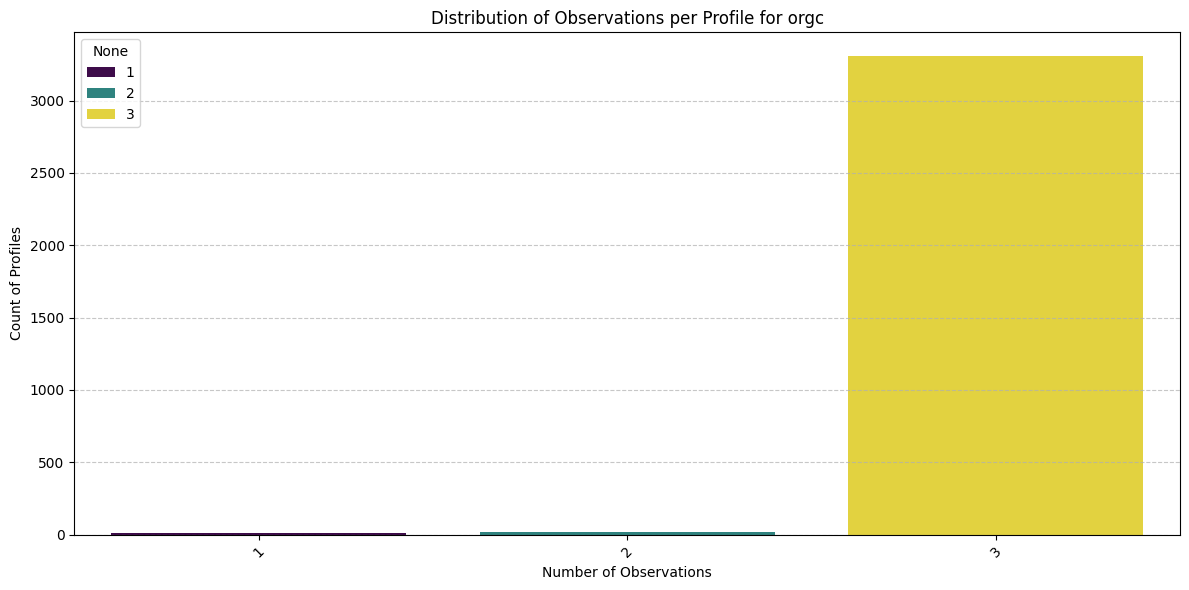

In [8]:
# Group data by profile_id and count observations
profile_counts = final_df.groupby('profile_id').size()

# Identify single observation profiles
single_obs_profiles = profile_counts[profile_counts == 1].index.tolist()
multi_obs_profiles = profile_counts[profile_counts > 1].index.tolist()

# Create separate dataframes for single and multiple observations
single_obs_df = final_df[final_df['profile_id'].isin(single_obs_profiles)]
multi_obs_df = final_df[final_df['profile_id'].isin(multi_obs_profiles)]

print(f"Number of profiles with single observation: {len(single_obs_profiles)}")
print(f"Number of profiles with multiple observations: {len(multi_obs_profiles)}")

# plotting the distribution of observations per profile
import matplotlib.pyplot as plt
import seaborn as sns

# Create a count plot for the number of observations per profile
plt.figure(figsize=(12, 6))
sns.countplot(x=profile_counts, hue=profile_counts, palette="viridis")
plt.title(f'Distribution of Observations per Profile for {target}')
plt.xlabel('Number of Observations')
plt.ylabel('Count of Profiles')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

def fill_missing_by_depth_and_location_with_tracking(df, features, lat_col='latitude', lon_col='longitude',
                                                      id_col='profile_id', depth_col='depth_category', invalid_value=-9999,
                                                      n_neighbors=5):
    """
    Fill missing or invalid feature values using nearest neighbors and track connections for plotting.
    """
    df = df.copy()
    connections = []  # Store info about who filled from whom

    # Replace invalid placeholders with NaN
    for feature in features:
        df[feature] = df[feature].replace(invalid_value, np.nan)

    filled_frames = []
    
    for depth_val, group in df.groupby(depth_col):
        valid = group.dropna(subset=features)
        invalid = group[group[features].isnull().any(axis=1)]

        if valid.empty or invalid.empty:
            filled_frames.append(group)
            continue

        # Create feature names for coordinates
        coord_features = [lat_col, lon_col]
        
        # Nearest neighbor model with feature names
        nbrs = NearestNeighbors(n_neighbors=min(n_neighbors, len(valid)), algorithm='ball_tree')
        nbrs.fit(valid[coord_features])

        for idx, row in invalid.iterrows():
            distances, indices = nbrs.kneighbors(row[coord_features].values.reshape(1, -1))
            neighbor_rows = valid.iloc[indices[0]]

            # Track neighbors with feature values
            for nidx, nrow in neighbor_rows.iterrows():
                connection_info = {
                    'target_profile': row[id_col],
                    'target_depth': row[depth_col],
                    'target_lat': row[lat_col],
                    'target_lon': row[lon_col],
                    'source_profile': nrow[id_col],
                    'source_depth': nrow[depth_col],
                    'source_lat': nrow[lat_col],
                    'source_lon': nrow[lon_col]
                }
                # Add feature values for verification
                for feature in features:
                    connection_info[f'source_{feature}'] = nrow[feature]
                    connection_info[f'target_{feature}'] = row[feature]
                
                connections.append(connection_info)

            # Average the neighbor values
            neighbor_values = neighbor_rows[features].mean()
            for feature in features:
                if pd.isna(row[feature]):
                    df.at[idx, feature] = neighbor_values[feature]

        filled_frames.append(df.loc[group.index])

    filled_df = pd.concat(filled_frames).sort_values([id_col, depth_col])
    connections_df = pd.DataFrame(connections)
    
    return filled_df, connections_df


In [10]:
def plot_depth_pie_chart(df):
    # drop duplicates
    df.drop_duplicates(subset=['profile_id', 'longitude', 'latitude', 'depth_category'], inplace=True)
    print(f"Number of rows after dropping duplicates: {df.shape[0]}")

    depth_counts = df.groupby(['profile_id'])[['depth_category']].size().value_counts().sort_index()

    # Create pie chart
    plt.figure(figsize=(10, 8))
    plt.pie(depth_counts.values, labels=[f'{count} depths: {freq} profiles' for count, freq in zip(depth_counts.index, depth_counts.values)], 
        autopct='%1.1f%%')
    plt.title('Distribution of Number of Depth Measurements per Profile Location')
    plt.axis('equal')
    plt.show()

import matplotlib.pyplot as plt

def plot_neighbor_connections(connections_df, title="Neighbor connections", annotate=False):
    """
    Plot connections between points used for filling missing data.
    """
    plt.figure(figsize=(10, 8))
    
    # Plot all arrows
    for _, row in connections_df.iterrows():
        plt.plot([row['target_lon'], row['source_lon']], [row['target_lat'], row['source_lat']],
                 color='gray', linestyle='--', alpha=0.5)

    # Plot target points
    plt.scatter(connections_df['target_lon'], connections_df['target_lat'],
                color='red', label='Missing (Filled)', s=50)
    
    # Annotate target points with profile_id
    if(annotate):
        for _, row in connections_df.drop_duplicates('target_profile').iterrows():
            plt.annotate(f'Target: {row["target_profile"]}', 
                        (row['target_lon'], row['target_lat']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8)

    # Plot source points
    plt.scatter(connections_df['source_lon'], connections_df['source_lat'],
                color='green', label='Neighbor Source', s=30)
    
    # Annotate source points with profile_id
    if(annotate):
        for _, row in connections_df.drop_duplicates('source_profile').iterrows():
            plt.annotate(f'Source: {row["source_profile"]}',
                        (row['source_lon'], row['source_lat']),
                        xytext=(5, -5), textcoords='offset points',
                        fontsize=8)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [11]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# test df with first 50 rows
test_df = merged_df.head(50).copy()

df_filled, connections_df = fill_missing_by_depth_and_location_with_tracking(merged_df, soil_features)
df_filled.head()

,profile_id,depth_category,date,longitude,latitude,clay,elcosp,phaq,sand,silt,orgc
0,1149115,0_5,2004-5-27,-92.924872,15.375747,11.473293,0.117950,5.917957,53.411810,35.114897,15.868971
2,1149115,15_30,2004-5-27,-92.924872,15.375747,13.443150,0.049220,5.854219,33.299825,53.257025,8.683302
1,1149115,5_15,2004-5-27,-92.924872,15.375747,11.914496,0.102914,5.902915,48.878541,39.206964,14.303404
3,1149116,0_5,2004-11-12,-93.805531,15.933933,10.241270,0.112064,5.824141,83.328428,6.430302,10.530031
5,1149116,15_30,2004-11-12,-93.805531,15.933933,8.340249,0.018339,6.449995,88.791135,2.868616,6.114025


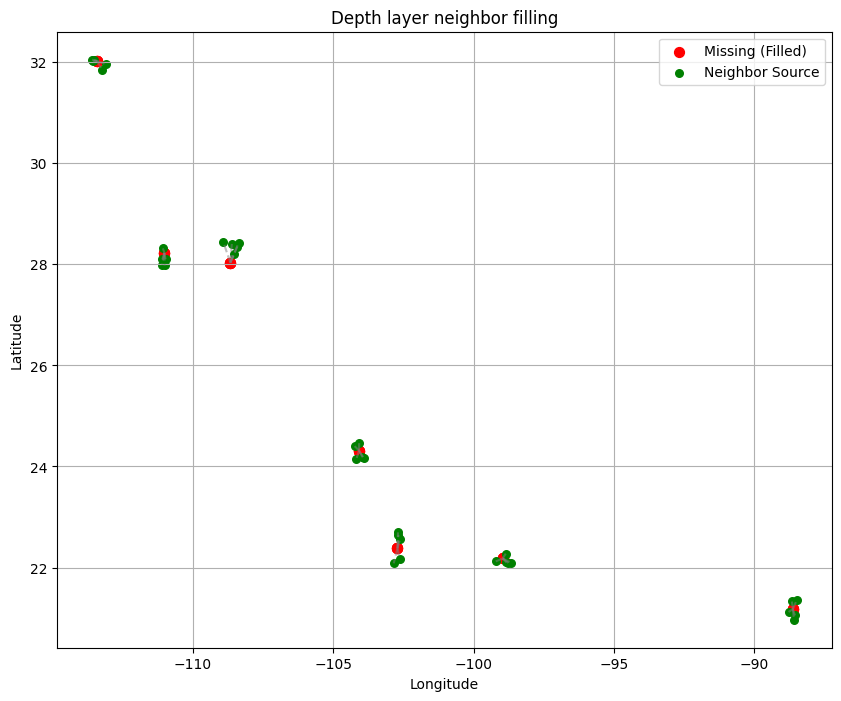

In [12]:
plot_neighbor_connections(connections_df, title="Depth layer neighbor filling")

In [13]:
test_df_filled, test_connections_df = fill_missing_by_depth_and_location_with_tracking(test_df, soil_features)
plot_neighbor_connections(test_connections_df, title="Depth layer neighbor filling", annotate=True)

KeyError: 'target_lon'

<Figure size 1000x800 with 0 Axes>

Number of rows after dropping duplicates: 50


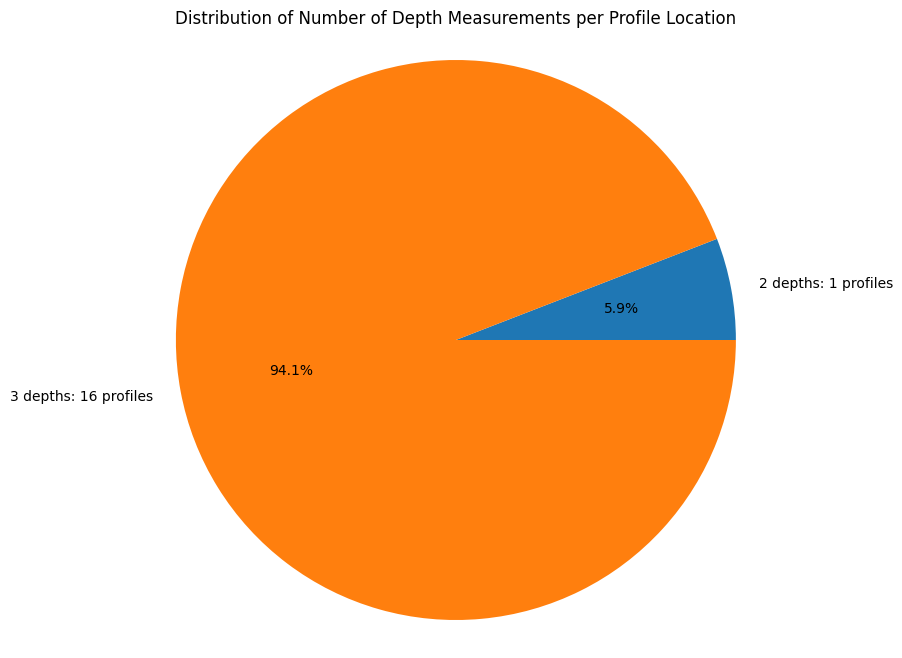

In [ ]:
plot_depth_pie_chart(df_filled)

In [ ]:
import os

# Count duplicates by profile_id and ignoring the depth_category
duplicate_counts = test_df.groupby(['profile_id', 'depth_category']).size().reset_index(name='count')
duplicate_counts = duplicate_counts[duplicate_counts['count'] > 1]

if duplicate_counts.empty:
    print("No duplicates found in the dataset.")
else:
    # Create a plot
    plt.figure(figsize=(12, 6))
    sns.countplot(data=duplicate_counts, x='count', hue='depth_category')
    plt.title('Number of Duplicates by Depth Category')
    plt.xlabel('Number of Duplicates')
    plt.ylabel('Frequency')
    plt.xticks(rotation=0)
    plt.legend(title='Depth Category')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("Summary of duplicates:")
    print(duplicate_counts['count'].value_counts().sort_index())

# Save the filled dataframe
output_filled_file = os.path.join(os.path.dirname(output_file), 'Mexico_standardized_filled.csv')
os.makedirs(os.path.dirname(output_filled_file), exist_ok=True)
df_filled.to_csv(output_filled_file, index=False)
print(f"Filled data saved to: {output_filled_file}")

# save the connections dataframe
connections_output_file = os.path.join(os.path.dirname(output_file), 'Mexico_standardized_connections.csv')
os.makedirs(os.path.dirname(connections_output_file), exist_ok=True)
connections_df.to_csv(connections_output_file, index=False)
print(f"Connections data saved to: {connections_output_file}")

No duplicates found in the dataset.
Filled data saved to: D:/tierra/outputs/harmonized\Mexico_standardized_filled.csv
Connections data saved to: D:/tierra/outputs/harmonized\Mexico_standardized_connections.csv
